# Retail Customer Analytics — Chips Category

**Context.** Quantium's retail analytics team was asked by the Category Manager for Chips to understand *who* buys chips and *how* they buy, so the insights can feed the supermarket's strategic plan for the category over the next half-year.

**Questions answered in this notebook**

1. Which customer segments drive chip sales?
2. Is that driven by *more customers*, *more units per customer*, or *higher prices per unit*?
3. Is the price difference between segments statistically significant?
4. What brands and pack sizes does the key segment prefer?

**Data.** 12 months of transactions (Jul 2018 – Jun 2019, ~265k rows) and a customer table with life stage and price-sensitivity segment (72k loyalty cards).

## 1. Setup

In [1]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Load data

In [2]:
transactions = pd.read_csv("data/QVI_transaction_data.csv")
customers = pd.read_csv("data/QVI_purchase_behaviour.csv")

print(f"Transactions: {transactions.shape[0]:,} rows x {transactions.shape[1]} columns")
print(f"Customers:    {customers.shape[0]:,} rows x {customers.shape[1]} columns")
transactions.head()

Transactions: 264,836 rows x 8 columns
Customers:    72,637 rows x 3 columns


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,43390,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00
1,43599,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30
2,43605,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90
3,43329,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00
4,43330,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80


In [3]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 264836 entries, 0 to 264835
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   DATE            264836 non-null  int64  
 1   STORE_NBR       264836 non-null  int64  
 2   LYLTY_CARD_NBR  264836 non-null  int64  
 3   TXN_ID          264836 non-null  int64  
 4   PROD_NBR        264836 non-null  int64  
 5   PROD_NAME       264836 non-null  str    
 6   PROD_QTY        264836 non-null  int64  
 7   TOT_SALES       264836 non-null  float64
dtypes: float64(1), int64(6), str(1)
memory usage: 16.2 MB


## 3. Cleaning the transaction data

### 3.1 Dates
`DATE` is stored as an Excel serial number (days since 1899-12-30). Convert it to a proper date.

In [4]:
transactions["DATE"] = pd.to_datetime(transactions["DATE"], origin="1899-12-30", unit="D")
transactions["DATE"].agg(["min", "max"])

min   2018-07-01
max   2019-06-30
Name: DATE, dtype: datetime64[s]

### 3.2 Keep only chips
The product names reveal some non-chip items. Looking at the most common words in product names helps spot them.

In [5]:
words = (
    pd.Series(transactions["PROD_NAME"].unique())
    .str.split()
    .explode()
    .loc[lambda s: s.str.fullmatch(r"[A-Za-z]+")]   # drop tokens with digits / symbols
)
words.value_counts().head(15)

Chips       21
Smiths      16
Crinkle     14
Cut         14
Kettle      13
Cheese      12
Salt        12
Original    10
Chip         9
Salsa        9
Doritos      9
Corn         8
Pringles     8
RRD          8
Chicken      7
Name: count, dtype: int64

*Salsa* products appear in the list — they are dips, not chips, so they are removed.

In [6]:
is_salsa = transactions["PROD_NAME"].str.contains("salsa", case=False)
print(f"Removing {is_salsa.sum():,} salsa transactions")
transactions = transactions.loc[~is_salsa].reset_index(drop=True)

Removing 18,094 salsa transactions


### 3.3 Missing values and outliers

In [7]:
print("Missing values per column:")
print(transactions.isna().sum().to_string())
transactions[["PROD_QTY", "TOT_SALES"]].describe()

Missing values per column:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0


,PROD_QTY,TOT_SALES
count,"246,742.00","246,742.00"
mean,1.91,7.32
std,0.66,3.08
min,1.00,1.70
25%,2.00,5.80
50%,2.00,7.40
75%,2.00,8.80
max,200.00,650.00


`PROD_QTY` has a maximum of 200 while the 75th percentile is 2. Let's look at it.

In [8]:
transactions.loc[transactions["PROD_QTY"] >= 100]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00


In [9]:
outlier_cards = transactions.loc[transactions["PROD_QTY"] >= 100, "LYLTY_CARD_NBR"].unique()
transactions.loc[transactions["LYLTY_CARD_NBR"].isin(outlier_cards)]

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
64955,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.00
64956,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.00


The same loyalty card bought 200 packets twice and has no other transactions — this looks like a commercial buyer, not a retail shopper. The whole card is removed so it doesn't distort per-customer metrics.

In [10]:
transactions = transactions.loc[~transactions["LYLTY_CARD_NBR"].isin(outlier_cards)].reset_index(drop=True)
transactions["PROD_QTY"].describe()

count   246,740.00
mean          1.91
std           0.34
min           1.00
25%           2.00
50%           2.00
75%           2.00
max           5.00
Name: PROD_QTY, dtype: float64

### 3.4 Gaps in the time series
A full year should have 365 days. Reindexing on a complete calendar shows which day is missing.

In [11]:
daily = transactions.groupby("DATE").size()
full_year = pd.date_range("2018-07-01", "2019-06-30", freq="D")
daily = daily.reindex(full_year, fill_value=0)

print(f"Days with transactions: {(daily > 0).sum()} of {len(full_year)}")
print("Days with zero transactions:", list(daily[daily == 0].index.date))

Days with transactions: 364 of 365
Days with zero transactions: [datetime.date(2018, 12, 25)]


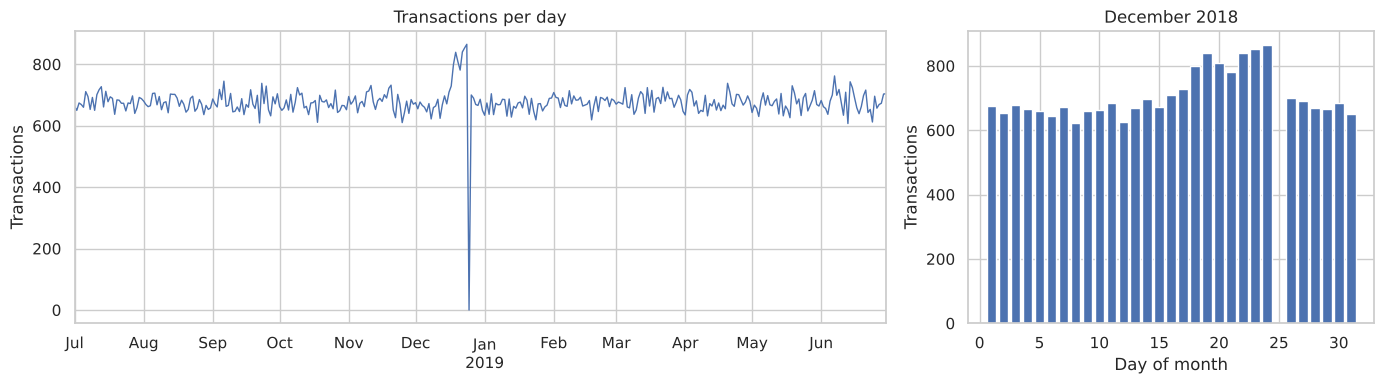

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [2, 1]})

daily.plot(ax=axes[0], lw=1)
axes[0].set(title="Transactions per day", xlabel="", ylabel="Transactions")

dec = daily.loc["2018-12-01":"2018-12-31"]
axes[1].bar(dec.index.day, dec.values, color=["C3" if v == 0 else "C0" for v in dec.values])
axes[1].set(title="December 2018", xlabel="Day of month", ylabel="Transactions")

plt.tight_layout()
plt.show()

**Finding:** sales ramp up in the lead-up to Christmas, and the only day with no transactions is **25 December**, when stores are closed. This is a real-world effect, not a data problem.

### 3.5 Feature engineering: pack size and brand
Pack size is the number before the `g` in the product name. The brand is the first word, but several brands are written in more than one way (e.g. `Red` / `RRD` for Red Rock Deli), so they are standardised.

In [13]:
transactions["PACK_SIZE"] = (
    transactions["PROD_NAME"].str.extract(r"(\d+)\s*[gG]", expand=False).astype(int)
)

brand_map = {
    "Red": "RRD", "Snbts": "Sunbites", "Infzns": "Infuzions", "WW": "Woolworths",
    "Smith": "Smiths", "NCC": "Natural", "Dorito": "Doritos", "Grain": "GrnWves",
}
transactions["BRAND"] = transactions["PROD_NAME"].str.split().str[0].replace(brand_map)

print("Pack sizes (g):", sorted(transactions["PACK_SIZE"].unique().tolist()))
transactions["BRAND"].value_counts()

Pack sizes (g): [70, 90, 110, 125, 134, 135, 150, 160, 165, 170, 175, 180, 190, 200, 210, 220, 250, 270, 330, 380]


BRAND
Kettle        41288
Smiths        30353
Doritos       25224
Pringles      25102
RRD           16321
Infuzions     14201
Thins         14075
Woolworths    11836
Cobs           9693
Tostitos       9471
Twisties       9454
GrnWves        7740
Natural        7469
Tyrrells       6442
Cheezels       4603
CCs            4551
Sunbites       3008
Cheetos        2927
Burger         1564
French         1418
Name: count, dtype: int64

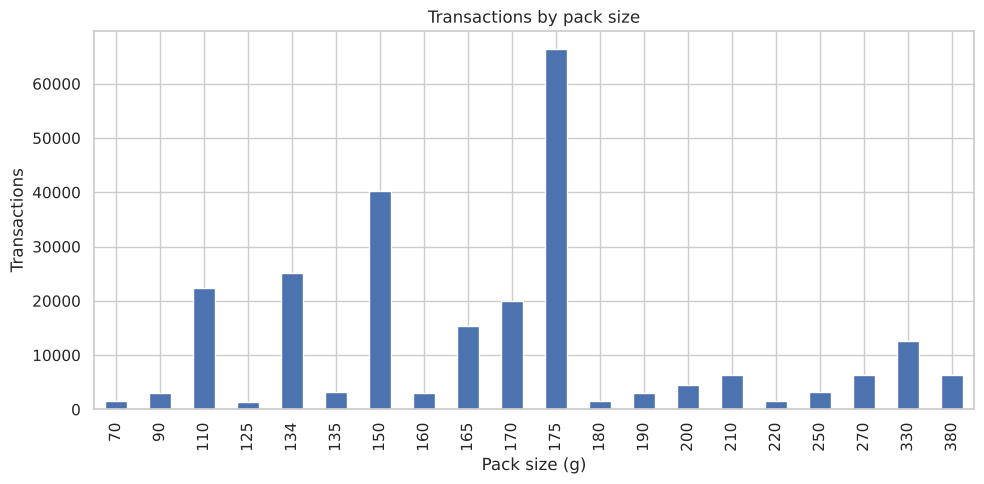

In [14]:
ax = transactions["PACK_SIZE"].value_counts().sort_index().plot.bar(color="C0")
ax.set(title="Transactions by pack size", xlabel="Pack size (g)", ylabel="Transactions")
plt.tight_layout()
plt.show()

Pack sizes range from 70 g to 380 g, with 175 g and 150 g by far the most common.

## 4. Customer data

In [15]:
print("Duplicate loyalty cards:", customers["LYLTY_CARD_NBR"].duplicated().sum())
print("Missing values:", customers.isna().sum().sum())
customers.head()

Duplicate loyalty cards: 0


Missing values: 0


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream


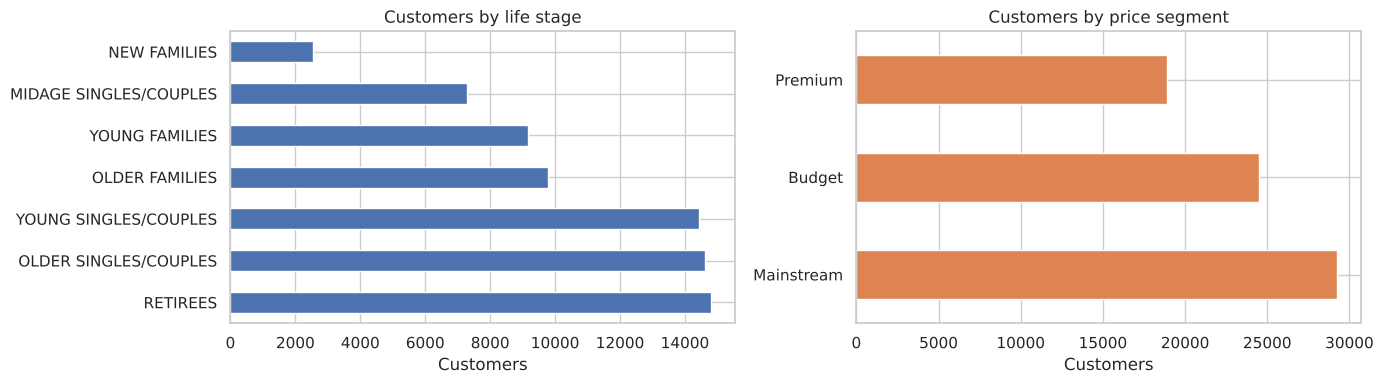

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
customers["LIFESTAGE"].value_counts().plot.barh(ax=axes[0], color="C0")
axes[0].set(title="Customers by life stage", xlabel="Customers", ylabel="")
customers["PREMIUM_CUSTOMER"].value_counts().plot.barh(ax=axes[1], color="C1")
axes[1].set(title="Customers by price segment", xlabel="Customers", ylabel="")
plt.tight_layout()
plt.show()

## 5. Merge

In [17]:
data = transactions.merge(customers, on="LYLTY_CARD_NBR", how="left", validate="many_to_one")

assert len(data) == len(transactions), "Merge changed the number of rows"
print("Transactions without a matching customer:", data["LIFESTAGE"].isna().sum())
data.head()

Transactions without a matching customer: 0


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.00,175,Natural,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.30,175,CCs,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.90,170,Smiths,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.00,175,Smiths,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.80,150,Kettle,MIDAGE SINGLES/COUPLES,Budget


## 6. Segment analysis

Each customer belongs to one *life stage* (e.g. young singles/couples, older families) and one *price segment* (Budget, Mainstream, Premium). All metrics below are computed per life stage × price segment.

The key metrics are decomposed as:

**Total sales = customers × units per customer × price per unit**

In [18]:
seg_cols = ["LIFESTAGE", "PREMIUM_CUSTOMER"]
segments = (
    data.groupby(seg_cols)
    .agg(
        total_sales=("TOT_SALES", "sum"),
        customers=("LYLTY_CARD_NBR", "nunique"),   # unique loyalty cards, not transactions
        units=("PROD_QTY", "sum"),
    )
    .assign(
        units_per_customer=lambda d: d["units"] / d["customers"],
        price_per_unit=lambda d: d["total_sales"] / d["units"],
        sales_share=lambda d: d["total_sales"] / d["total_sales"].sum(),
    )
    .reset_index()
    .sort_values("total_sales", ascending=False)
)
segments.head(10)

,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,customers,units,units_per_customer,price_per_unit,sales_share
6,OLDER FAMILIES,Budget,"156,863.75",4611,41853,9.08,3.75,0.09
19,YOUNG SINGLES/COUPLES,Mainstream,"147,582.20",7917,36225,4.58,4.07,0.08
13,RETIREES,Mainstream,"145,168.95",6358,37677,5.93,3.85,0.08
15,YOUNG FAMILIES,Budget,"129,717.95",3953,34482,8.72,3.76,0.07
9,OLDER SINGLES/COUPLES,Budget,"127,833.60",4849,32883,6.78,3.89,0.07
10,OLDER SINGLES/COUPLES,Mainstream,"124,648.50",4858,32607,6.71,3.82,0.07
11,OLDER SINGLES/COUPLES,Premium,"123,537.55",4682,31695,6.77,3.90,0.07
12,RETIREES,Budget,"105,916.30",4385,26932,6.14,3.93,0.06
7,OLDER FAMILIES,Mainstream,"96,413.55",2788,25804,9.26,3.74,0.05
14,RETIREES,Premium,"91,296.65",3812,23266,6.10,3.92,0.05


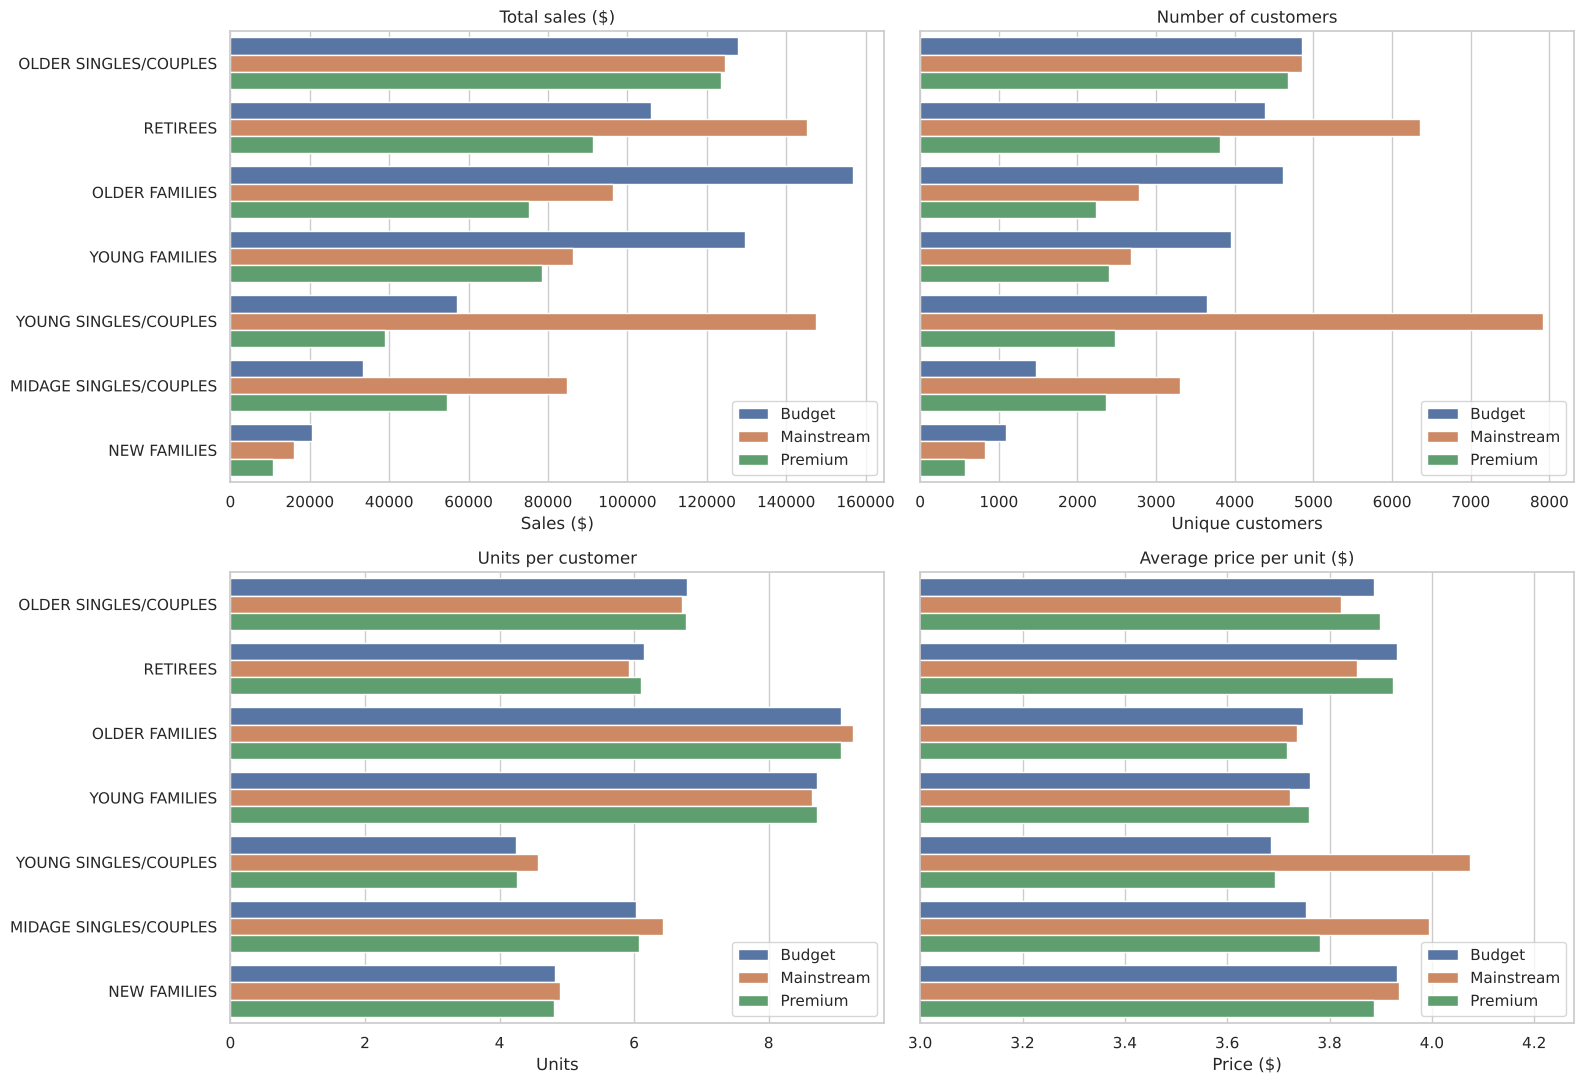

In [19]:
lifestage_order = (
    segments.groupby("LIFESTAGE")["total_sales"].sum().sort_values(ascending=False).index
)
price_order = ["Budget", "Mainstream", "Premium"]

def segment_bar(metric, title, ylabel, ax):
    sns.barplot(
        data=segments, y="LIFESTAGE", x=metric, hue="PREMIUM_CUSTOMER",
        order=lifestage_order, hue_order=price_order, ax=ax,
    )
    ax.set(title=title, xlabel=ylabel, ylabel="")
    ax.legend(title="", loc="lower right")

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=True)
segment_bar("total_sales", "Total sales ($)", "Sales ($)", axes[0, 0])
segment_bar("customers", "Number of customers", "Unique customers", axes[0, 1])
segment_bar("units_per_customer", "Units per customer", "Units", axes[1, 0])
segment_bar("price_per_unit", "Average price per unit ($)", "Price ($)", axes[1, 1])
axes[1, 1].set_xlim(3.0, None)
plt.tight_layout()
plt.show()

In [20]:
top3 = segments.head(3)[seg_cols + ["total_sales", "sales_share", "customers"]]
top3

,LIFESTAGE,PREMIUM_CUSTOMER,total_sales,sales_share,customers
6,OLDER FAMILIES,Budget,"156,863.75",0.09,4611
19,YOUNG SINGLES/COUPLES,Mainstream,"147,582.20",0.08,7917
13,RETIREES,Mainstream,"145,168.95",0.08,6358


**Reading the four panels together:**

- **Sales** are concentrated in *Budget – Older Families*, *Mainstream – Young Singles/Couples* and *Mainstream – Retirees*.
- For **Mainstream young singles/couples and retirees**, the driver is **number of customers** — they are the two largest customer groups.
- **Families** (older and young) buy the **most units per customer**.
- **Mainstream young and midage singles/couples** pay a **higher price per unit** than their Budget and Premium peers — this is typical of impulse purchases.

The last point is tested formally below.

## 7. Is the price difference significant?

Compare the price per unit paid by *Mainstream* vs *Budget + Premium* customers within **young and midage singles/couples**, using Welch's t-test (does not assume equal variances).

In [21]:
data["PRICE_PER_UNIT"] = data["TOT_SALES"] / data["PROD_QTY"]
singles = data["LIFESTAGE"].isin(["YOUNG SINGLES/COUPLES", "MIDAGE SINGLES/COUPLES"])

mainstream = data.loc[singles & (data["PREMIUM_CUSTOMER"] == "Mainstream"), "PRICE_PER_UNIT"]
others = data.loc[singles & (data["PREMIUM_CUSTOMER"] != "Mainstream"), "PRICE_PER_UNIT"]

t_stat, p_value = stats.ttest_ind(mainstream, others, equal_var=False, alternative="greater")

print(f"Mean price per unit — Mainstream:         ${mainstream.mean():.3f}  (n={len(mainstream):,})")
print(f"Mean price per unit — Budget + Premium:   ${others.mean():.3f}  (n={len(others):,})")
print(f"Welch t = {t_stat:.1f}, one-sided p = {p_value:.2e}")

Mean price per unit — Mainstream:         $4.040  (n=30,639)
Mean price per unit — Budget + Premium:   $3.706  (n=26,728)
Welch t = 37.6, one-sided p = 3.48e-306


**Result:** the p-value is far below 0.05, so Mainstream young and midage singles/couples pay **significantly more per packet** than Budget or Premium customers of the same life stage.

## 8. Deep dive: Mainstream young singles/couples

This segment is one of the top contributors to sales and pays a premium per unit, so it is worth targeting. Which brands and pack sizes do they over-index on compared with everyone else?

**Affinity** = (share of the target segment's units) / (share of all other customers' units). Values above 1 mean the segment buys that item more than the rest of the market.

In [22]:
target = (data["LIFESTAGE"] == "YOUNG SINGLES/COUPLES") & (data["PREMIUM_CUSTOMER"] == "Mainstream")

def affinity(column):
    seg = data.loc[target].groupby(column)["PROD_QTY"].sum()
    rest = data.loc[~target].groupby(column)["PROD_QTY"].sum()
    out = pd.DataFrame({"target_share": seg / seg.sum(), "rest_share": rest / rest.sum()})
    out["affinity"] = out["target_share"] / out["rest_share"]
    return out.sort_values("affinity", ascending=False)

brand_aff = affinity("BRAND")
pack_aff = affinity("PACK_SIZE")
brand_aff.head(8)

,target_share,rest_share,affinity
BRAND,,,
Tyrrells,0.03,0.03,1.23
Twisties,0.05,0.04,1.22
Doritos,0.12,0.10,1.21
Kettle,0.20,0.17,1.20
Tostitos,0.05,0.04,1.20
Pringles,0.12,0.10,1.19
Cobs,0.04,0.04,1.14
Infuzions,0.06,0.06,1.13


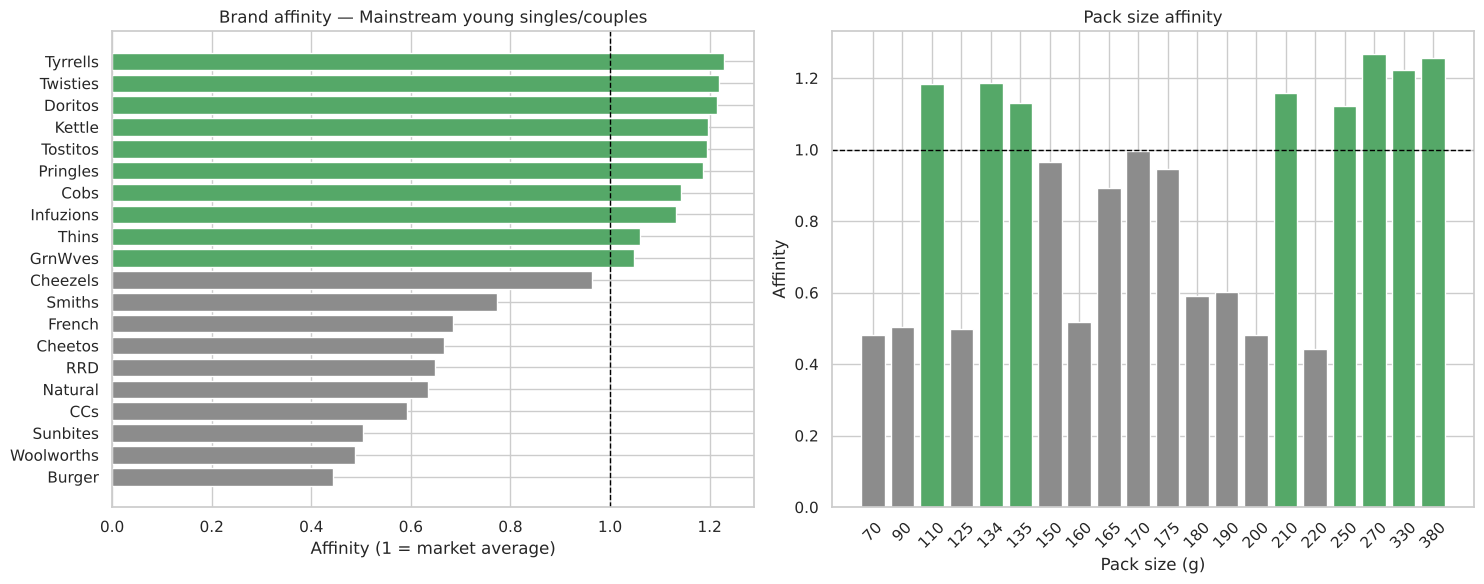

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

b = brand_aff["affinity"].sort_values()
axes[0].barh(b.index, b.values, color=["C2" if v > 1 else "C7" for v in b.values])
axes[0].axvline(1, color="black", lw=1, ls="--")
axes[0].set(title="Brand affinity — Mainstream young singles/couples", xlabel="Affinity (1 = market average)")

p = pack_aff["affinity"].sort_index()
axes[1].bar(p.index.astype(str), p.values, color=["C2" if v > 1 else "C7" for v in p.values])
axes[1].axhline(1, color="black", lw=1, ls="--")
axes[1].set(title="Pack size affinity", xlabel="Pack size (g)", ylabel="Affinity")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [24]:
print("Products sold in 270 g packs:")
print(data.loc[data["PACK_SIZE"] == 270, "PROD_NAME"].unique())

Products sold in 270 g packs:
<StringArray>
['Twisties Cheese     270g', 'Twisties Chicken270g']
Length: 2, dtype: str


## 9. Conclusions and recommendations

In [25]:
s = segments.set_index(seg_cols)
summary = pd.DataFrame({
    "Sales share": s["sales_share"].map("{:.1%}".format),
    "Customers": s["customers"].map("{:,}".format),
    "Units / customer": s["units_per_customer"].round(2),
    "Price / unit ($)": s["price_per_unit"].round(2),
}).head(3)
summary

,,Sales share,Customers,Units / customer,Price / unit ($)
LIFESTAGE,PREMIUM_CUSTOMER,,,,
OLDER FAMILIES,Budget,8.7%,"4,611",9.08,3.75
YOUNG SINGLES/COUPLES,Mainstream,8.2%,"7,917",4.58,4.07
RETIREES,Mainstream,8.0%,"6,358",5.93,3.85


**Key findings**

1. **Three segments drive the category:** Budget older families, Mainstream young singles/couples and Mainstream retirees.
2. **Different levers:** retirees and young singles/couples win on *number of customers*; older families win on *units per customer*.
3. **Mainstream young and midage singles/couples pay more per packet** than their Budget and Premium peers — a statistically significant difference (Welch's t-test, p ≪ 0.001), consistent with impulse buying.
4. **Mainstream young singles/couples over-index on branded chips** — Tyrrells, Twisties, Doritos, Kettle and Pringles (~20% above the rest of the market) — and on **larger packs (270–380 g)**, while under-indexing on value and private-label brands such as Woolworths, Sunbites and Burger Rings (~50% below).

**Recommendations for the Category Manager**

- **Shelf placement for impulse buying:** place Tyrrells, Twisties, Doritos and Kettle in high-visibility spots frequented by young singles/couples (e.g. near checkouts, convenience/express formats).
- **Promote larger packs to the key segment:** the affinity for 270–380 g packs suggests appetite for sharing formats; test promotions on large packs of the preferred brands.
- **Keep volume offers for families:** families buy the most units per customer — multi-buy deals support this behaviour without discounting the impulse segment.
- **Next step:** run a controlled trial (store-level test vs control) to measure the uplift of any layout change before rolling it out.